In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.io import loadmat
import pandas as pd
import numpy as np
import mne
import os
from sklearn.model_selection import ShuffleSplit, cross_val_score, train_test_split
from mne.decoding import CSP

In [2]:
### Reading all files
path = 'data/david_20200123_session1_0'
ext = '.mat'
data = pd.DataFrame()
for i in range(1, 9):
    filename = path + str(i) + ext
    file_data = loadmat(filename)
    mdata = file_data['data']
    temp = pd.DataFrame(mdata)
    data = pd.concat([data, temp])
data.shape

(1327616, 73)

In [2]:
path = 'data/david_20200123_session1_0'
ext = '.mat'
filename = path + str(1) + ext
file_data = loadmat(filename)
mdata = file_data['data']
print(mdata)

[[17.10598073 24.55488849 15.00535623 ...  0.53881795  0.14079624
   0.        ]
 [19.29664243 25.93449812 16.17486787 ...  0.64584984  0.63352018
   0.        ]
 [21.2583171  27.14255094 17.20827251 ...  0.73918614  1.07323684
   0.        ]
 ...
 [ 3.71455184  0.19194549  1.35717588 ... -0.93921468 -0.62711815
   0.        ]
 [ 3.26232924  0.44941957  1.40817311 ... -0.75960109 -0.4986512
   0.        ]
 [ 2.54056207  0.51980169  1.21424698 ... -0.55465387 -0.35949891
   0.        ]]


In [3]:
type(mdata)

numpy.ndarray

In [3]:
temp = pd.DataFrame(mdata)
temp

,0,1,2,3,4,5,6,7,8,9,...,63,64,65,66,67,68,69,70,71,72
0,-57.952110,-57.607757,-50.563208,-38.152809,-42.293750,-38.214592,-14.006037,-20.004542,-23.436210,-58.458748,...,67.651158,-25.692464,9.172808,-0.092191,0.347348,0.503138,0.033096,0.510049,0.660220,0.0
1,-60.674644,-61.634790,-53.052154,-41.033526,-44.885809,-41.784597,-20.714449,-25.099269,-25.938864,-60.344101,...,69.104389,-24.148943,8.901644,0.046995,0.455211,0.898278,0.192390,0.218677,0.688968,0.0
2,-63.080755,-65.084071,-55.167435,-43.432450,-47.007418,-44.819212,-26.506178,-29.477794,-28.058442,-61.862161,...,70.254896,-22.418926,8.352686,0.182989,0.548890,1.226026,0.311564,-0.044590,0.703274,0.0
3,-64.957941,-67.642671,-56.697701,-45.060134,-48.411067,-47.003645,-30.898283,-32.732370,-29.588076,-62.837259,...,70.933565,-20.761283,7.614533,0.305042,0.622336,1.464439,0.374668,-0.252783,0.712618,0.0
4,-66.202705,-69.139753,-57.563406,-45.820866,-48.996390,-48.183165,-33.613106,-34.716646,-30.448498,-63.206164,...,71.003472,-19.290261,6.709628,0.405442,0.672860,1.612793,0.384136,-0.396468,0.723001,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72187,-66.688258,-12.307188,6.200398,6.713645,26.443862,53.734263,-23.031884,-9.919421,-0.900873,4.893628,...,8.068660,-22.303417,20.965594,0.150515,-0.137253,0.217990,1.469553,-0.322774,-0.247915,0.0
72188,-59.679293,-7.392134,10.097233,9.175118,28.737415,55.776481,-21.219983,-8.217550,0.856960,6.753870,...,7.153815,-19.679470,21.734531,0.176543,-0.169279,0.201896,1.328606,-0.297509,-0.254054,0.0
72189,-50.321061,-3.272886,12.209575,10.273262,28.315367,53.052786,-18.629474,-6.108225,2.528853,7.703075,...,5.971714,-16.668663,20.396376,0.191061,-0.175749,0.173334,1.139413,-0.261790,-0.242962,0.0
72190,-39.345865,-0.439879,12.166012,9.813604,25.023053,45.651088,-15.192135,-4.035359,3.534407,7.504882,...,4.616818,-13.270640,17.231081,0.183602,-0.158473,0.136688,0.909249,-0.214320,-0.211883,0.0


In [3]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,63,64,65,66,67,68,69,70,71,72
0,17.105981,24.554888,15.005356,12.292314,15.023244,18.086515,20.015809,14.553146,13.430839,7.616764,...,-5.800183,2.146358,-10.774213,0.102805,-0.498674,-0.264332,-0.534325,0.538818,0.140796,0.0
1,19.296642,25.934498,16.174868,14.147057,15.824592,18.721176,20.827001,12.537479,12.982798,7.100069,...,-3.546706,5.790218,-8.863672,0.140478,-0.377666,-0.064091,-0.349212,0.645850,0.633520,0.0
2,21.258317,27.142551,17.208273,15.722504,16.394587,19.218464,21.415916,10.801487,12.409850,6.527207,...,-1.539948,8.929023,-7.180271,0.171621,-0.258195,0.123417,-0.173290,0.739186,1.073237,0.0
3,22.788739,28.009005,17.972828,16.786124,16.550509,19.432372,21.545947,9.363138,11.577936,5.851425,...,0.022522,11.243235,-5.915357,0.192651,-0.156389,0.276135,-0.032065,0.817128,1.420439,0.0
4,23.763603,28.410634,18.393665,17.216624,16.218170,19.279510,21.136680,8.262744,10.453829,5.081501,...,1.065431,12.660267,-5.114605,0.200139,-0.075091,0.388460,0.063033,0.875565,1.660915,0.0


cols = np.arange(73)
columns = []
[columns.append(str(x)) for x in cols]
columns

In [4]:
cols = np.arange(73)
columns = []
[columns.append(str(x)) for x in cols]
columns

['0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '70',
 '71',
 '72']

In [5]:
data = data.values

In [6]:
df = pd.DataFrame(data, columns=columns)
df

,0,1,2,3,4,5,6,7,8,9,...,63,64,65,66,67,68,69,70,71,72
0,17.105981,24.554888,15.005356,12.292314,15.023244,18.086515,20.015809,14.553146,13.430839,7.616764,...,-5.800183,2.146358,-10.774213,0.102805,-0.498674,-0.264332,-0.534325,0.538818,0.140796,0.0
1,19.296642,25.934498,16.174868,14.147057,15.824592,18.721176,20.827001,12.537479,12.982798,7.100069,...,-3.546706,5.790218,-8.863672,0.140478,-0.377666,-0.064091,-0.349212,0.645850,0.633520,0.0
2,21.258317,27.142551,17.208273,15.722504,16.394587,19.218464,21.415916,10.801487,12.409850,6.527207,...,-1.539948,8.929023,-7.180271,0.171621,-0.258195,0.123417,-0.173290,0.739186,1.073237,0.0
3,22.788739,28.009005,17.972828,16.786124,16.550509,19.432372,21.545947,9.363138,11.577936,5.851425,...,0.022522,11.243235,-5.915357,0.192651,-0.156389,0.276135,-0.032065,0.817128,1.420439,0.0
4,23.763603,28.410634,18.393665,17.216624,16.218170,19.279510,21.136680,8.262744,10.453829,5.081501,...,1.065431,12.660267,-5.114605,0.200139,-0.075091,0.388460,0.063033,0.875565,1.660915,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1327611,-66.688258,-12.307188,6.200398,6.713645,26.443862,53.734263,-23.031884,-9.919421,-0.900873,4.893628,...,8.068660,-22.303417,20.965594,0.150515,-0.137253,0.217990,1.469553,-0.322774,-0.247915,0.0
1327612,-59.679293,-7.392134,10.097233,9.175118,28.737415,55.776481,-21.219983,-8.217550,0.856960,6.753870,...,7.153815,-19.679470,21.734531,0.176543,-0.169279,0.201896,1.328606,-0.297509,-0.254054,0.0
1327613,-50.321061,-3.272886,12.209575,10.273262,28.315367,53.052786,-18.629474,-6.108225,2.528853,7.703075,...,5.971714,-16.668663,20.396376,0.191061,-0.175749,0.173334,1.139413,-0.261790,-0.242962,0.0
1327614,-39.345865,-0.439879,12.166012,9.813604,25.023053,45.651088,-15.192135,-4.035359,3.534407,7.504882,...,4.616818,-13.270640,17.231081,0.183602,-0.158473,0.136688,0.909249,-0.214320,-0.211883,0.0


In [7]:
df = df.drop(['66','67','68','69','70','71'], axis=1)
df

,0,1,2,3,4,5,6,7,8,9,...,57,58,59,60,61,62,63,64,65,72
0,17.105981,24.554888,15.005356,12.292314,15.023244,18.086515,20.015809,14.553146,13.430839,7.616764,...,-4.884054,-8.754141,-15.292612,-14.702328,-9.591363,-6.502740,-5.800183,2.146358,-10.774213,0.0
1,19.296642,25.934498,16.174868,14.147057,15.824592,18.721176,20.827001,12.537479,12.982798,7.100069,...,-2.840955,-6.756346,-12.365625,-12.139328,-7.196754,-4.378569,-3.546706,5.790218,-8.863672,0.0
2,21.258317,27.142551,17.208273,15.722504,16.394587,19.218464,21.415916,10.801487,12.409850,6.527207,...,-0.934861,-4.926926,-9.776067,-9.946174,-5.021252,-2.459225,-1.539948,8.929023,-7.180271,0.0
3,22.788739,28.009005,17.972828,16.786124,16.550509,19.432372,21.545947,9.363138,11.577936,5.851425,...,0.679172,-3.425621,-7.784500,-8.359430,-3.257660,-0.929891,0.022522,11.243235,-5.915357,0.0
4,23.763603,28.410634,18.393665,17.216624,16.218170,19.279510,21.136680,8.262744,10.453829,5.081501,...,1.925060,-2.330924,-6.486737,-7.469046,-1.991829,0.127604,1.065431,12.660267,-5.114605,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1327611,-66.688258,-12.307188,6.200398,6.713645,26.443862,53.734263,-23.031884,-9.919421,-0.900873,4.893628,...,-5.355067,-0.913621,9.363581,11.669632,7.845282,0.702661,8.068660,-22.303417,20.965594,0.0
1327612,-59.679293,-7.392134,10.097233,9.175118,28.737415,55.776481,-21.219983,-8.217550,0.856960,6.753870,...,-4.331903,-0.187122,9.071474,11.116026,7.231547,0.802464,7.153815,-19.679470,21.734531,0.0
1327613,-50.321061,-3.272886,12.209575,10.273262,28.315367,53.052786,-18.629474,-6.108225,2.528853,7.703075,...,-3.353013,0.301763,8.124683,9.804395,6.212872,0.787766,5.971714,-16.668663,20.396376,0.0
1327614,-39.345865,-0.439879,12.166012,9.813604,25.023053,45.651088,-15.192135,-4.035359,3.534407,7.504882,...,-2.453568,0.528175,6.638810,7.905156,4.905434,0.674558,4.616818,-13.270640,17.231081,0.0


In [8]:
columns.remove('66')
columns.remove('67')
columns.remove('68')
columns.remove('69')
columns.remove('70')
columns.remove('71')

In [9]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,57,58,59,60,61,62,63,64,65,72
0,17.105981,24.554888,15.005356,12.292314,15.023244,18.086515,20.015809,14.553146,13.430839,7.616764,...,-4.884054,-8.754141,-15.292612,-14.702328,-9.591363,-6.502740,-5.800183,2.146358,-10.774213,0.0
1,19.296642,25.934498,16.174868,14.147057,15.824592,18.721176,20.827001,12.537479,12.982798,7.100069,...,-2.840955,-6.756346,-12.365625,-12.139328,-7.196754,-4.378569,-3.546706,5.790218,-8.863672,0.0
2,21.258317,27.142551,17.208273,15.722504,16.394587,19.218464,21.415916,10.801487,12.409850,6.527207,...,-0.934861,-4.926926,-9.776067,-9.946174,-5.021252,-2.459225,-1.539948,8.929023,-7.180271,0.0
3,22.788739,28.009005,17.972828,16.786124,16.550509,19.432372,21.545947,9.363138,11.577936,5.851425,...,0.679172,-3.425621,-7.784500,-8.359430,-3.257660,-0.929891,0.022522,11.243235,-5.915357,0.0
4,23.763603,28.410634,18.393665,17.216624,16.218170,19.279510,21.136680,8.262744,10.453829,5.081501,...,1.925060,-2.330924,-6.486737,-7.469046,-1.991829,0.127604,1.065431,12.660267,-5.114605,0.0


In [10]:
sfreq = 512
info = mne.create_info(ch_names=columns, sfreq=sfreq, ch_types='eeg')

Creating RawArray with float64 data, n_channels=67, n_times=1327616
    Range : 0 ... 1327615 =      0.000 ...  2592.998 secs
Ready.


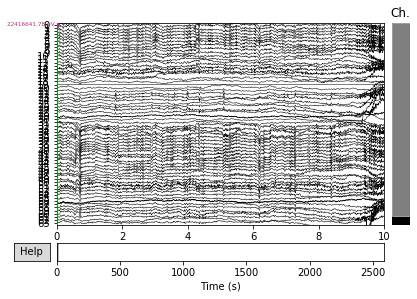

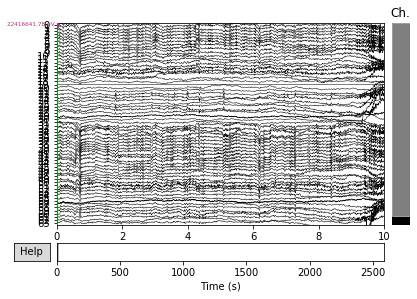

In [11]:
raw = mne.io.RawArray(df.T, info)
scalings = 'auto'
raw.plot(n_channels=64, scalings=scalings, title='Auto-scaled Data from arrays',
         show=True, block=True)

In [12]:
events = mne.find_events(raw, stim_channel='72')
print(events[:5])  # show the first 5

180 events found
Event IDs: [1 2 3 4]
[[ 8989     0     3]
 [14390     0     1]
 [19797     0     3]
 [25206     0     2]
 [30629     0     2]]


In [13]:
event_dict = {'Long/Hands': 1, 'Medium/Hands': 2, 'Short/Hands': 3,
              'Relax': 4}

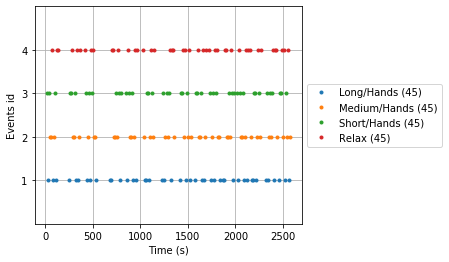

In [14]:
fig = mne.viz.plot_events(events, event_id=event_dict, sfreq=raw.info['sfreq'])
fig.subplots_adjust(right=0.7)  # make room for the legend

In [15]:
fig.savefig('4_class_events.pdf', bbox_inches='tight')

In [16]:
epochs = mne.Epochs(raw, events, event_id=event_dict, tmin=-0.1, tmax=6
                    , preload=True)

180 matching events found
Applying baseline correction (mode: mean)
Not setting metadata
0 projection items activated
Loading data for 180 events and 3124 original time points ...
0 bad epochs dropped


In [17]:
labels = epochs.events[:, -1]

In [18]:
epochs_data = epochs.get_data()

In [19]:
epochs_data.shape

(180, 67, 3124)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(epochs_data, labels, test_size=0.2, random_state=42)

In [20]:
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

In [21]:
X_train_csp = csp.fit_transform(X_train, y_train)

Computing data rank from raw with rank=None
    Using tolerance 4.5e+02 (2.2e-16 eps * 67 dim * 3e+16  max singular value)
    Estimated rank (mag): 67
    MAG: rank 67 computed from 67 data channels with 0 projectors
Reducing data rank from 67 -> 67
Estimating covariance using EMPIRICAL
Done.
Computing data rank from raw with rank=None
    Using tolerance 2e+02 (2.2e-16 eps * 67 dim * 1.3e+16  max singular value)
    Estimated rank (mag): 67
    MAG: rank 67 computed from 67 data channels with 0 projectors
Reducing data rank from 67 -> 67
Estimating covariance using EMPIRICAL
Done.
Computing data rank from raw with rank=None
    Using tolerance 2.6e+02 (2.2e-16 eps * 67 dim * 1.8e+16  max singular value)
    Estimated rank (mag): 67
    MAG: rank 67 computed from 67 data channels with 0 projectors
Reducing data rank from 67 -> 67
Estimating covariance using EMPIRICAL
Done.
Computing data rank from raw with rank=None
    Using tolerance 2.4e+02 (2.2e-16 eps * 67 dim * 1.6e+16  max sing

In [22]:
X_test_csp = csp.transform(X_test)

In [23]:
y_test

array([1, 3, 3, 3, 2, 4, 4, 4, 1, 2, 4, 2, 3, 1, 3, 2, 3, 2, 1, 2, 3, 1,
       4, 4, 1, 2, 4, 3, 3, 4, 3, 1, 2, 3, 1, 1])

In [23]:
X_test_csp

array([[-2.23489711,  0.10621321, -0.58387084,  0.11568562],
       [ 0.47313161, -0.98503071,  1.17168822,  0.31576515],
       [-0.1045864 , -0.53541259, -0.70741777, -0.72592011],
       [ 0.32810279, -0.93861272, -0.92295644, -0.37710778],
       [-1.12375141, -0.6478917 , -0.5483928 , -0.34049329],
       [ 0.47640998, -0.55056321, -0.31107669, -0.63976013],
       [ 0.82598054,  1.96416516, -0.52659546, -0.52561881],
       [ 1.04598615, -0.13369209, -1.15763827, -1.57152682],
       [-1.73667647, -0.70494642,  0.22419522, -0.76272546],
       [-0.80915652, -0.86024561,  0.60624856, -0.727414  ],
       [ 0.83956074, -0.64521372, -0.94343632, -1.3938056 ],
       [-1.14724197, -0.73087626,  0.05317072, -0.58750955],
       [-0.1067008 , -0.52481245, -0.70979347, -0.71257307],
       [-2.21766858,  0.5780585 , -1.22586536,  0.69193206],
       [ 0.26126002, -0.4253364 , -1.24520012, -1.11636102],
       [-0.89542015, -0.9415161 ,  0.91485243,  0.20226362],
       [-0.03554256, -0.

In [25]:
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV

In [26]:
param = {'C' : [ 0.1, 1, 10, 50, 100, 1000], 'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 'kernel': ['rbf', 'linear']}
svm = SVC()

In [27]:
grid = GridSearchCV(svm, param, cv=15, scoring='accuracy', return_train_score=True, verbose=1)

In [28]:
grid.fit(X_train_csp, y_train)

Fitting 15 folds for each of 60 candidates, totalling 900 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 900 out of 900 | elapsed:    2.7s finished
/home/rohit/anaconda3/lib/python3.7/site-packages/sklearn/model_selection/_search.py:814: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


GridSearchCV(cv=15, error_score='raise-deprecating',
             estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
                           decision_function_shape='ovr', degree=3,
                           gamma='auto_deprecated', kernel='rbf', max_iter=-1,
                           probability=False, random_state=None, shrinking=True,
                           tol=0.001, verbose=False),
             iid='warn', n_jobs=None,
             param_grid={'C': [0.1, 1, 10, 50, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'linear']},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
             scoring='accuracy', verbose=1)

In [29]:
print(grid.best_params_)
print(grid.best_estimator_)

{'C': 1000, 'gamma': 0.01, 'kernel': 'rbf'}
SVC(C=1000, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma=0.01, kernel='rbf',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)


In [30]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import cohen_kappa_score

In [31]:
y_pred = grid.predict(X_test_csp)

In [32]:
accuracy_score(y_test, y_pred)

0.8888888888888888

In [33]:
cohen_kappa_score(y_test, y_pred)

0.8509316770186335

In [34]:
from sklearn.dummy import DummyClassifier

In [35]:
dummy = DummyClassifier()

In [36]:
dummy.fit(X_train_csp, y_train)

DummyClassifier(constant=None, random_state=None, strategy='stratified')

In [37]:
dummy_pred = dummy.predict(X_test_csp)

In [47]:
print(accuracy_score(y_test, dummy_pred))
print(cohen_kappa_score(y_test, dummy_pred))

0.2222222222222222
-0.03490759753593431


In [40]:
param = {'solver' : ['lsqr', 'eigen'], 'shrinkage' : [None, 'auto']}
lda = LinearDiscriminantAnalysis()

grid = GridSearchCV(lda, param, cv=15, scoring='accuracy', return_train_score=True, verbose=1)
grid.fit(X_train_csp, y_train)

Fitting 15 folds for each of 4 candidates, totalling 60 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  60 out of  60 | elapsed:    0.3s finished
/home/rohit/anaconda3/lib/python3.7/site-packages/sklearn/model_selection/_search.py:814: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


GridSearchCV(cv=15, error_score='raise-deprecating',
             estimator=LinearDiscriminantAnalysis(n_components=None,
                                                  priors=None, shrinkage=None,
                                                  solver='svd',
                                                  store_covariance=False,
                                                  tol=0.0001),
             iid='warn', n_jobs=None,
             param_grid={'shrinkage': [None, 'auto'],
                         'solver': ['lsqr', 'eigen']},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
             scoring='accuracy', verbose=1)

In [41]:
print(grid.best_params_)
print(grid.best_estimator_)

{'shrinkage': None, 'solver': 'lsqr'}
LinearDiscriminantAnalysis(n_components=None, priors=None, shrinkage=None,
                           solver='lsqr', store_covariance=False, tol=0.0001)


In [42]:
y_pred = grid.predict(X_test_csp)
print(accuracy_score(y_test, y_pred))
print(cohen_kappa_score(y_test, y_pred))

0.9722222222222222
0.9626168224299065


In [24]:
import mne
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf
from mne.time_frequency import tfr_multitaper
from mne.stats import permutation_cluster_1samp_test as pcluster_test
from mne.viz.utils import center_cmap

In [25]:
# compute ERDS maps ###########################################################
freqs = np.arange(2, 36, 1)  # frequencies from 2-35Hz
n_cycles = freqs  # use constant t/f resolution
vmin, vmax = -1, 1.5  # set min and max ERDS values in plot
baseline = [-1, 0]  # baseline interval (in s)
cmap = center_cmap(plt.cm.RdBu, vmin, vmax)  # zero maps to white
kwargs = dict(n_permutations=100, step_down_p=0.05, seed=1,
              buffer_size=None)  # for cluster test

In [ ]:
# Run TF decomposition overall epochs
tfr = tfr_multitaper(epochs, freqs=freqs, n_cycles=n_cycles,
                     use_fft=True, return_itc=False, average=False,
                     decim=2)
tfr.crop(-0.5, 6.5)
tfr.apply_baseline(baseline, mode="percent")

In [ ]:
for event in event_ids:
    # select desired epochs for visualization
    tfr_ev = tfr[event]
    fig, axes = plt.subplots(1, 4, figsize=(12, 4),
                             gridspec_kw={"width_ratios": [10, 10, 10, 1]})
    for ch, ax in enumerate(axes[:-1]):  # for each channel
        # positive clusters
        _, c1, p1, _ = pcluster_test(tfr_ev.data[:, ch, ...], tail=1, **kwargs)
        # negative clusters
        _, c2, p2, _ = pcluster_test(tfr_ev.data[:, ch, ...], tail=-1,
                                     **kwargs)

        # note that we keep clusters with p <= 0.05 from the combined clusters
        # of two independent tests; in this example, we do not correct for
        # these two comparisons
        c = np.stack(c1 + c2, axis=2)  # combined clusters
        p = np.concatenate((p1, p2))  # combined p-values
        mask = c[..., p <= 0.05].any(axis=-1)

        # plot TFR (ERDS map with masking)
        tfr_ev.average().plot([ch], vmin=vmin, vmax=vmax, cmap=(cmap, False),
                              axes=ax, colorbar=False, show=False, mask=mask,
                              mask_style="mask")

        ax.set_title(epochs.ch_names[ch], fontsize=10)
        ax.axvline(0, linewidth=1, color="black", linestyle=":")  # event
        if not ax.is_first_col():
            ax.set_ylabel("")
            ax.set_yticklabels("")
    fig.colorbar(axes[0].images[-1], cax=axes[-1])
    fig.suptitle("ERDS ({})".format(event))
    fig.show()